<a href="https://colab.research.google.com/github/SAMIULLAH168/ml-project/blob/main/Time_Space_Complexity_Big_O_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Time Space Complexity Big O

🎓 STUDENT PERFORMANCE PREDICTOR
Machine Learning Project with Complexity Analysis

📊 PART 1: LOADING DATA (O(n))
----------------------------------------

📝 Using sample dataset with 5000 students
Features: ['hours_studied', 'previous_score', 'sleep_hours', 'attendance', 'tutoring_sessions', 'internet_access', 'parent_education', 'extracurricular']
Target: exam_score
   hours_studied  previous_score  sleep_hours  attendance  tutoring_sessions  \
0              7              48            9          79                  5   
1             15              74            8          55                  6   
2             11              47            9          51                  5   
3              8              63            6          63                  1   
4              7              58            5          90                  3   

   internet_access  parent_education  extracurricular  exam_score  
0                0                 3                1       100.0  
1            

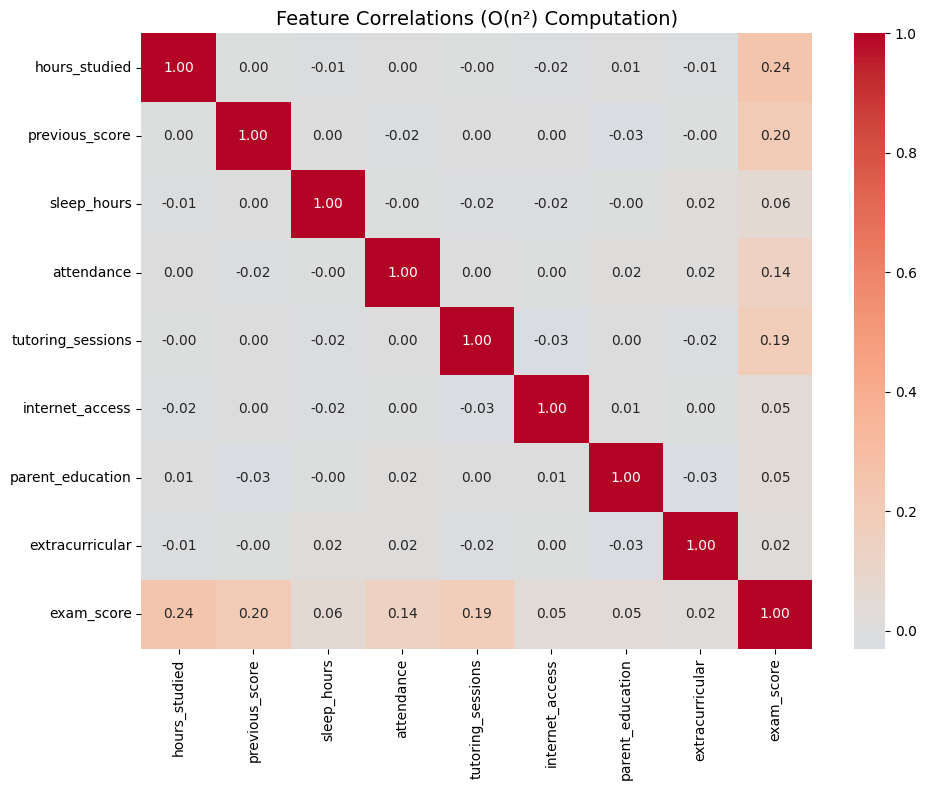



✂️ PART 4: SPLITTING DATA (O(n))
----------------------------------------
Training set: 4000 samples
Test set: 1000 samples


🤖 PART 5: MODEL TRAINING
----------------------------------------

🚀 Training models...

📊 Linear Regression:
   Train time: 0.006s | Predict: 0.001s
   R² Score: 0.107 | MAE: 1.46
   Complexity: O(n * d² + d³) ≈ O(4000 × 8²)
   CV Score: 0.164 ± 0.022

📊 Ridge Regression:
   Train time: 0.002s | Predict: 0.000s
   R² Score: 0.107 | MAE: 1.46
   Complexity: O(n * d² + d³) ≈ O(4000 × 8²)
   CV Score: 0.164 ± 0.022

📊 Lasso Regression:
   Train time: 0.003s | Predict: 0.000s
   R² Score: -0.004 | MAE: 1.16
   Complexity: O(n * d²) ≈ O(4000 × 8²)
   CV Score: -0.002 ± 0.002

📊 Random Forest:
   Train time: 0.730s | Predict: 0.018s
   R² Score: 0.410 | MAE: 0.76
   Complexity: O(n_estimators × n × log n) ≈ O(100 × 4000 × log(4000))
   CV Score: 0.438 ± 0.071

📊 Gradient Boosting:
   Train time: 0.456s | Predict: 0.004s
   R² Score: 0.362 | MAE: 0.92
   Complexity:

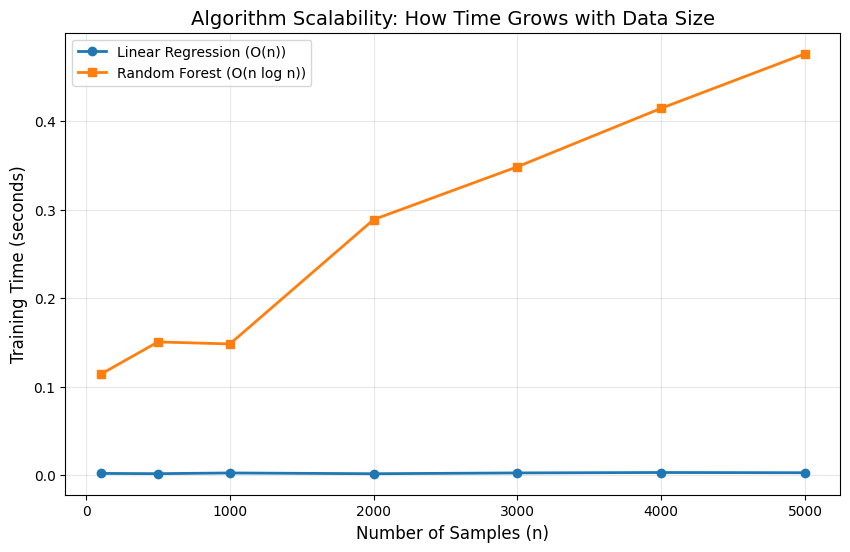



🎯 PART 7: MAKING PREDICTIONS
----------------------------------------
🏆 Best Model: Random Forest
   R² Score: 0.410
   Training Time: 0.730s


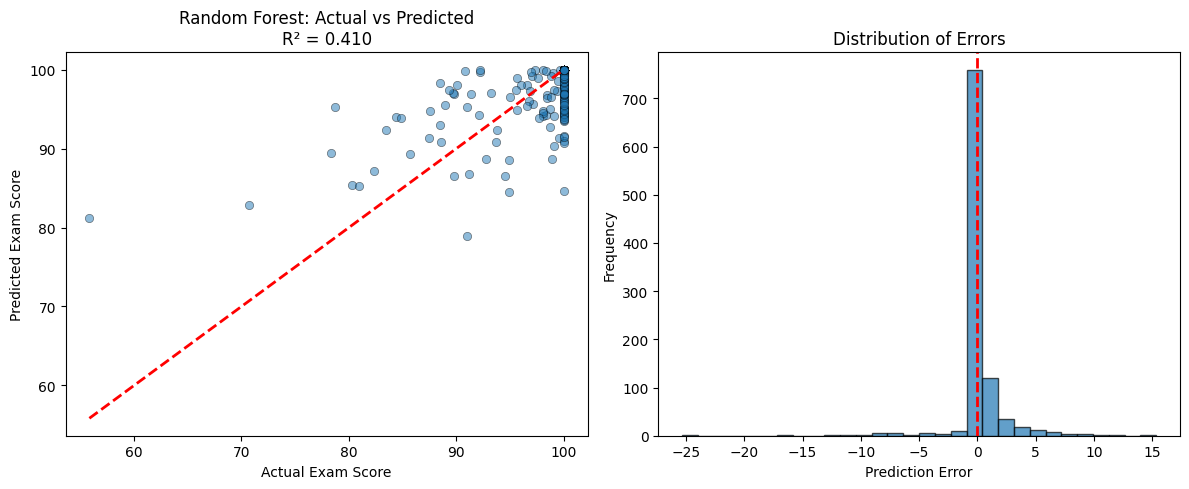



🔮 PART 8: PREDICT NEW STUDENTS
----------------------------------------

📝 Sample Predictions:

Student 1:
  hours_studied: 15
  previous_score: 85
  sleep_hours: 8
  attendance: 95
  tutoring_sessions: 4
  internet_access: 1
  parent_education: 4
  extracurricular: 1
  🎯 Predicted Exam Score: 100.0

Student 2:
  hours_studied: 5
  previous_score: 60
  sleep_hours: 5
  attendance: 70
  tutoring_sessions: 0
  internet_access: 0
  parent_education: 1
  extracurricular: 0
  🎯 Predicted Exam Score: 97.2


📋 COMPLEXITY ANALYSIS SUMMARY

Time Complexities in this Project:

1. LOADING DATA: O(n)
   - Reading CSV scales linearly with rows

2. PREPROCESSING: O(n)
   - Missing value imputation
   - Feature scaling
   - Label encoding

3. CORRELATION MATRIX: O(n²)
   - Computing correlations between all feature pairs
   - n = number of features

4. TRAIN-TEST SPLIT: O(n)
   - Random shuffling and splitting

5. MODEL TRAINING:
   - Linear/Ridge/Lasso: O(n × d²)
   - Random Forest: O(n_estimators

In [ ]:
# ============================================
# STUDENT PERFORMANCE PREDICTOR
# Complete ML Project for Kaggle
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("🎓 STUDENT PERFORMANCE PREDICTOR")
print("Machine Learning Project with Complexity Analysis")
print("=" * 60)

# ============================================
# PART 1: LOAD DATA (O(n) - Linear)
# ============================================

print("\n📊 PART 1: LOADING DATA (O(n))")
print("-" * 40)

def load_data(file_path):
    """
    O(n) - Loading data scales with file size
    """
    start = time()

    # Reading CSV is O(n) - processes each row once
    df = pd.read_csv(file_path)

    end = time()
    print(f"✓ Loaded {len(df)} rows in {end-start:.2f} seconds")
    print(f"✓ Features: {df.shape[1]}")
    print(f"✓ Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    return df

# For Kaggle, you'll load like this:
# df = load_data('/kaggle/input/student-performance/student-mat.csv')

# SAMPLE DATA (if no dataset available)
# This creates realistic student data for testing
def create_sample_data(n_students=1000):
    """
    O(n) - Creates artificial dataset
    """
    np.random.seed(42)

    data = {
        'hours_studied': np.random.randint(1, 20, n_students),
        'previous_score': np.random.randint(40, 100, n_students),
        'sleep_hours': np.random.randint(4, 10, n_students),
        'attendance': np.random.randint(50, 100, n_students),
        'tutoring_sessions': np.random.randint(0, 10, n_students),
        'internet_access': np.random.choice([0, 1], n_students),
        'parent_education': np.random.choice([1, 2, 3, 4], n_students),
        'extracurricular': np.random.choice([0, 1], n_students),
    }

    # Create target variable (exam score) based on features
    data['exam_score'] = (
        data['hours_studied'] * 2.5 +
        data['previous_score'] * 0.6 +
        data['sleep_hours'] * 1.2 +
        data['attendance'] * 0.5 +
        data['tutoring_sessions'] * 3 +
        data['internet_access'] * 5 +
        data['parent_education'] * 2 +
        data['extracurricular'] * 4 +
        np.random.normal(0, 10, n_students)
    )

    # Clip scores to 0-100 range
    data['exam_score'] = np.clip(data['exam_score'], 0, 100)

    return pd.DataFrame(data)

# Use sample data for now
df = create_sample_data(5000)
print(f"\n📝 Using sample dataset with {len(df)} students")
print(f"Features: {list(df.columns)[:-1]}")
print(f"Target: exam_score")
print(df.head())

# ============================================
# PART 2: DATA PREPROCESSING (O(n))
# ============================================

print("\n\n🔧 PART 2: DATA PREPROCESSING (O(n))")
print("-" * 40)

class DataPreprocessor:
    """
    All operations are O(n) - process each row once
    """

    def __init__(self):
        self.scaler = StandardScaler()
        self.encoders = {}

    def handle_missing_values(self, df):
        """
        O(n) - Checks each column once
        """
        start = time()

        missing = df.isnull().sum()
        if missing.sum() > 0:
            print(f"⚠️ Found {missing.sum()} missing values")
            # Fill with median (O(n))
            for col in df.columns:
                if df[col].isnull().any():
                    df[col].fillna(df[col].median(), inplace=True)
        else:
            print("✓ No missing values found")

        print(f"  Time: {time()-start:.3f} seconds")
        return df

    def encode_categorical(self, df):
        """
        O(n) - Transforms each value once
        """
        start = time()

        categorical_cols = df.select_dtypes(include=['object']).columns

        for col in categorical_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            self.encoders[col] = le
            print(f"  ✓ Encoded {col}")

        print(f"  Time: {time()-start:.3f} seconds")
        return df

    def scale_features(self, X):
        """
        O(n) - Scales each value
        """
        start = time()

        X_scaled = self.scaler.fit_transform(X)

        print(f"  Scaled {X.shape[1]} features")
        print(f"  Time: {time()-start:.3f} seconds")
        return X_scaled

# Preprocess data
preprocessor = DataPreprocessor()
df = preprocessor.handle_missing_values(df)

# Separate features and target
target_col = 'exam_score'
X = df.drop(columns=[target_col])
y = df[target_col]

# Scale features
X_scaled = preprocessor.scale_features(X)

print(f"\n✓ Final shapes - X: {X_scaled.shape}, y: {y.shape}")

# ============================================
# PART 3: FEATURE CORRELATION (O(n²))
# ============================================

print("\n\n📈 PART 3: FEATURE CORRELATION (O(n²))")
print("-" * 40)

def analyze_correlations(df, target_col):
    """
    O(n²) - Computes correlation between every pair of features
    """
    start = time()

    # Correlation matrix is O(n²) where n is number of features
    correlation_matrix = df.corr()

    # Find correlations with target
    target_correlations = correlation_matrix[target_col].sort_values(ascending=False)

    end = time()
    print(f"✓ Calculated {len(correlation_matrix)}² = {len(correlation_matrix)**2} correlations")
    print(f"✓ Time: {end-start:.3f} seconds")

    print("\n📊 Top 5 features correlated with exam_score:")
    for feature, corr in target_correlations.head(6).items():
        if feature != target_col:
            print(f"  {feature}: {corr:.3f}")

    return correlation_matrix

# Calculate correlations (O(n²) operation)
corr_matrix = analyze_correlations(df, target_col)

# Visualize correlation matrix (O(n²) to create heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Feature Correlations (O(n²) Computation)", fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# PART 4: TRAIN-TEST SPLIT (O(n))
# ============================================

print("\n\n✂️ PART 4: SPLITTING DATA (O(n))")
print("-" * 40)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# ============================================
# PART 5: MODEL TRAINING WITH COMPLEXITY ANALYSIS
# ============================================

print("\n\n🤖 PART 5: MODEL TRAINING")
print("-" * 40)

class ModelComplexityAnalyzer:
    """
    Analyzes time complexity of different ML models
    """

    def __init__(self):
        self.models = {
            'Linear Regression': LinearRegression(),
            'Ridge Regression': Ridge(alpha=1.0),
            'Lasso Regression': Lasso(alpha=1.0),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
            'Gradient Boosting': GradientBoostingRegressor(random_state=42)
        }
        self.results = {}

    def get_complexity(self, model_name, n_samples, n_features):
        """
        Theoretical time complexity for each model
        """
        complexities = {
            'Linear Regression': f'O(n * d² + d³) ≈ O({n_samples} × {n_features}²)',
            'Ridge Regression': f'O(n * d² + d³) ≈ O({n_samples} × {n_features}²)',
            'Lasso Regression': f'O(n * d²) ≈ O({n_samples} × {n_features}²)',
            'Random Forest': f'O(n_estimators × n × log n) ≈ O(100 × {n_samples} × log({n_samples}))',
            'Gradient Boosting': f'O(n_estimators × n × d) ≈ O(100 × {n_samples} × {n_features})'
        }
        return complexities.get(model_name, "Unknown")

    def train_and_evaluate(self, X_train, y_train, X_test, y_test):
        """
        Train all models and measure actual time
        """
        print("\n🚀 Training models...\n")

        for name, model in self.models.items():
            start = time()

            # Training (complexity depends on algorithm)
            model.fit(X_train, y_train)
            train_time = time() - start

            # Prediction (usually O(n) or O(n log n))
            start_pred = time()
            y_pred = model.predict(X_test)
            pred_time = time() - start_pred

            # Calculate metrics (O(n))
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)

            # Cross-validation (O(k) more, k=5 folds)
            start_cv = time()
            cv_scores = cross_val_score(model, X_train, y_train, cv=5)
            cv_time = time() - start_cv

            self.results[name] = {
                'train_time': train_time,
                'pred_time': pred_time,
                'cv_time': cv_time,
                'mae': mae,
                'rmse': rmse,
                'r2': r2,
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std()
            }

            complexity = self.get_complexity(name, len(X_train), X_train.shape[1])

            print(f"📊 {name}:")
            print(f"   Train time: {train_time:.3f}s | Predict: {pred_time:.3f}s")
            print(f"   R² Score: {r2:.3f} | MAE: {mae:.2f}")
            print(f"   Complexity: {complexity}")
            print(f"   CV Score: {self.results[name]['cv_mean']:.3f} ± {self.results[name]['cv_std']:.3f}")
            print()

        return self.results

    def plot_results(self):
        """
        Visualize model performance
        """
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Plot 1: R² Scores (higher is better)
        models = list(self.results.keys())
        r2_scores = [self.results[m]['r2'] for m in models]

        axes[0].barh(models, r2_scores, color='skyblue')
        axes[0].set_xlabel('R² Score')
        axes[0].set_title('Model Accuracy (R²)')
        axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

        # Plot 2: Training Time
        train_times = [self.results[m]['train_time'] for m in models]

        axes[1].barh(models, train_times, color='lightcoral')
        axes[1].set_xlabel('Time (seconds)')
        axes[1].set_title('Training Time (Complexity)')

        # Plot 3: MAE (lower is better)
        mae_scores = [self.results[m]['mae'] for m in models]

        axes[2].barh(models, mae_scores, color='lightgreen')
        axes[2].set_xlabel('Mean Absolute Error')
        axes[2].set_title('Prediction Error (MAE)')

        plt.tight_layout()
        plt.show()

# Run model analysis
analyzer = ModelComplexityAnalyzer()
results = analyzer.train_and_evaluate(X_train, y_train, X_test, y_test)

# ============================================
# PART 6: SCALABILITY TEST (O(n²) Growth)
# ============================================

print("\n\n📈 PART 6: SCALABILITY TEST")
print("-" * 40)
print("Testing how training time grows with data size...")

def test_scalability():
    """
    Tests how model training time scales with dataset size
    Demonstrates O(n), O(n log n), O(n²) growth
    """
    sample_sizes = [100, 500, 1000, 2000, 3000, 4000, 5000]
    times_linear = []
    times_tree = []

    print("\n📊 Testing Random Forest (O(n log n)) vs Linear Regression (O(n))")
    print("-" * 50)

    for size in sample_sizes:
        # Create sample data
        X_sample = X_scaled[:size]
        y_sample = y[:size]

        # Linear Regression (theoretical O(n))
        start = time()
        lr = LinearRegression()
        lr.fit(X_sample, y_sample)
        times_linear.append(time() - start)

        # Random Forest (theoretical O(n log n))
        start = time()
        rf = RandomForestRegressor(n_estimators=50, random_state=42)
        rf.fit(X_sample, y_sample)
        times_tree.append(time() - start)

        print(f"  n={size:4d} → Linear: {times_linear[-1]:.3f}s | RF: {times_tree[-1]:.3f}s")

    # Plot scalability
    plt.figure(figsize=(10, 6))
    plt.plot(sample_sizes, times_linear, 'o-', label='Linear Regression (O(n))', linewidth=2)
    plt.plot(sample_sizes, times_tree, 's-', label='Random Forest (O(n log n))', linewidth=2)
    plt.xlabel('Number of Samples (n)', fontsize=12)
    plt.ylabel('Training Time (seconds)', fontsize=12)
    plt.title('Algorithm Scalability: How Time Grows with Data Size', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return times_linear, times_tree

scalability_results = test_scalability()

# ============================================
# PART 7: BEST MODEL PREDICTIONS
# ============================================

print("\n\n🎯 PART 7: MAKING PREDICTIONS")
print("-" * 40)

# Find best model
best_model_name = max(results, key=lambda x: results[x]['r2'])
best_model = analyzer.models[best_model_name]
best_r2 = results[best_model_name]['r2']

print(f"🏆 Best Model: {best_model_name}")
print(f"   R² Score: {best_r2:.3f}")
print(f"   Training Time: {results[best_model_name]['train_time']:.3f}s")

# Make predictions on test set
y_pred_best = best_model.predict(X_test)

# Visualize predictions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.5, edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Exam Score')
axes[0].set_ylabel('Predicted Exam Score')
axes[0].set_title(f'{best_model_name}: Actual vs Predicted\nR² = {best_r2:.3f}')

# Plot 2: Residuals
residuals = y_test - y_pred_best
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Errors')

plt.tight_layout()
plt.show()

# ============================================
# PART 8: SAMPLE PREDICTION FUNCTION
# ============================================

print("\n\n🔮 PART 8: PREDICT NEW STUDENTS")
print("-" * 40)

def predict_student_score(model, scaler, student_data):
    """
    O(1) - Single prediction is constant time
    """
    # Convert to DataFrame
    student_df = pd.DataFrame([student_data])

    # Scale features (O(d) where d is features)
    student_scaled = scaler.transform(student_df)

    # Predict (O(1) for most models)
    prediction = model.predict(student_scaled)[0]

    return prediction

# Example predictions
sample_students = [
    {
        'hours_studied': 15,
        'previous_score': 85,
        'sleep_hours': 8,
        'attendance': 95,
        'tutoring_sessions': 4,
        'internet_access': 1,
        'parent_education': 4,
        'extracurricular': 1
    },
    {
        'hours_studied': 5,
        'previous_score': 60,
        'sleep_hours': 5,
        'attendance': 70,
        'tutoring_sessions': 0,
        'internet_access': 0,
        'parent_education': 1,
        'extracurricular': 0
    }
]

print("\n📝 Sample Predictions:")
for i, student in enumerate(sample_students, 1):
    score = predict_student_score(best_model, preprocessor.scaler, student)
    print(f"\nStudent {i}:")
    for key, value in student.items():
        print(f"  {key}: {value}")
    print(f"  🎯 Predicted Exam Score: {score:.1f}")

# ============================================
# SUMMARY REPORT
# ============================================

print("\n\n" + "=" * 60)
print("📋 COMPLEXITY ANALYSIS SUMMARY")
print("=" * 60)

print("""
Time Complexities in this Project:

1. LOADING DATA: O(n)
   - Reading CSV scales linearly with rows

2. PREPROCESSING: O(n)
   - Missing value imputation
   - Feature scaling
   - Label encoding

3. CORRELATION MATRIX: O(n²)
   - Computing correlations between all feature pairs
   - n = number of features

4. TRAIN-TEST SPLIT: O(n)
   - Random shuffling and splitting

5. MODEL TRAINING:
   - Linear/Ridge/Lasso: O(n × d²)
   - Random Forest: O(n_estimators × n × log n)
   - Gradient Boosting: O(n_estimators × n × d)

6. PREDICTION: O(1) to O(n)
   - Single prediction: O(1)
   - Batch prediction: O(m) where m = batch size
""")

# Display final results table
results_df = pd.DataFrame(results).T
print("\n📊 MODEL COMPARISON TABLE:")
print(results_df[['r2', 'mae', 'train_time', 'pred_time']].round(4))

print("\n" + "=" * 60)
print("✅ PROJECT COMPLETE!")
print("=" * 60)

# ============================================
# HOW TO USE ON KAGGLE:
# ============================================

print("""
📌 HOW TO RUN THIS ON KAGGLE:

1. Go to kaggle.com and create a new Notebook

2. Add Dataset:
   - Click "Add Data" → Search for "Student Performance"
   - Or use any regression dataset

3. Modify the load_data() function:
   df = pd.read_csv('/kaggle/input/your-dataset/your-file.csv')

4. Update feature names to match your dataset

5. Run all cells!

🎯 TEST YOURSELF:
   - Try different dataset sizes to see O(n) growth
   - Add more features to see O(n²) correlation matrix
   - Compare training times between models
""")